In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Retail_Sales_Demand_Forecasting_30000.csv")

In [10]:
df.shape

(30000, 20)

In [11]:
df.head()

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Sub_Category,Customer_ID,Customer_Name,Region,City,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Mode,Customer_Segment,Inventory_Level,Supplier_ID
0,ORD114060,2024-01-01,P017,Mouse,Accessories,Computer Accessories,C4504,Customer_4504,South,Madurai,2,849.82,0.0,1699.64,1151.14,548.50,UPI,Home Office,117,SUP119
1,ORD101248,2024-01-01,P019,Power Bank,Accessories,Computer Accessories,C4193,Customer_4193,West,Pune,1,1745.85,0.2,1396.68,926.98,469.70,UPI,Corporate,113,SUP111
2,ORD110128,2024-01-01,P021,Coffee,Grocery,Food & Beverage,C3582,Customer_3582,North,Delhi,2,444.83,0.0,889.66,610.59,279.07,Net Banking,Corporate,93,SUP130
3,ORD126785,2024-01-01,P013,Sofa,Furniture,Home & Office,C5245,Customer_5245,South,Trichy,5,27934.26,0.2,111737.04,80363.24,31373.80,UPI,Consumer,83,SUP103
4,ORD126664,2024-01-01,P010,Vacuum Cleaner,Home Appliances,Appliances,C2614,Customer_2614,South,Trichy,3,9265.91,0.1,25017.96,20420.84,4597.12,UPI,Consumer,120,SUP108


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          30000 non-null  object 
 1   Order_Date        30000 non-null  object 
 2   Product_ID        30000 non-null  object 
 3   Product_Name      30000 non-null  object 
 4   Category          30000 non-null  object 
 5   Sub_Category      30000 non-null  object 
 6   Customer_ID       30000 non-null  object 
 7   Customer_Name     30000 non-null  object 
 8   Region            30000 non-null  object 
 9   City              30000 non-null  object 
 10  Quantity          30000 non-null  int64  
 11  Unit_Price        30000 non-null  float64
 12  Discount          30000 non-null  float64
 13  Sales             30000 non-null  float64
 14  Cost              30000 non-null  float64
 15  Profit            30000 non-null  float64
 16  Payment_Mode      30000 non-null  object

In [13]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Product_ID          0
Product_Name        0
Category            0
Sub_Category        0
Customer_ID         0
Customer_Name       0
Region              0
City                0
Quantity            0
Unit_Price          0
Discount            0
Sales               0
Cost                0
Profit              0
Payment_Mode        0
Customer_Segment    0
Inventory_Level     0
Supplier_ID         0
dtype: int64

In [14]:
df.describe()

,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Inventory_Level
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2.850800,16094.379637,0.089082,41732.939821,29214.319897,12518.619924,77.129167
std,1.852778,18166.743865,0.067034,62009.292660,43671.449759,19367.871236,42.086779
min,1.000000,225.080000,0.000000,172.520000,112.860000,32.510000,5.000000
25%,1.000000,1007.442500,0.050000,2989.370000,2057.187500,833.880000,41.000000
50%,2.000000,8907.855000,0.100000,17381.395000,12102.720000,4971.150000,77.000000
75%,4.000000,25587.767500,0.150000,53668.242500,37380.222500,15642.787500,114.000000
max,8.000000,72778.810000,0.250000,544479.430000,389323.050000,227584.920000,150.000000


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
df = df.drop_duplicates()

In [18]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [19]:
df[["Sales", "Cost", "Profit", "Quantity"]].sum()

Sales       1.251988e+09
Cost        8.764296e+08
Profit      3.755586e+08
Quantity    8.552400e+04
dtype: float64

In [20]:
df[["Sales", "Cost", "Profit", "Quantity"]].mean()

Sales       41732.939821
Cost        29214.319897
Profit      12518.619924
Quantity        2.850800
dtype: float64

In [21]:
category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(
    "Sales", ascending=False
)

category_analysis

,Sales,Profit
Category,,
Electronics,5.953739e+08,1.784795e+08
Home Appliances,4.247312e+08,1.273353e+08
Furniture,1.982513e+08,5.963064e+07
Accessories,2.665641e+07,8.021763e+06
Grocery,6.975395e+06,2.091334e+06


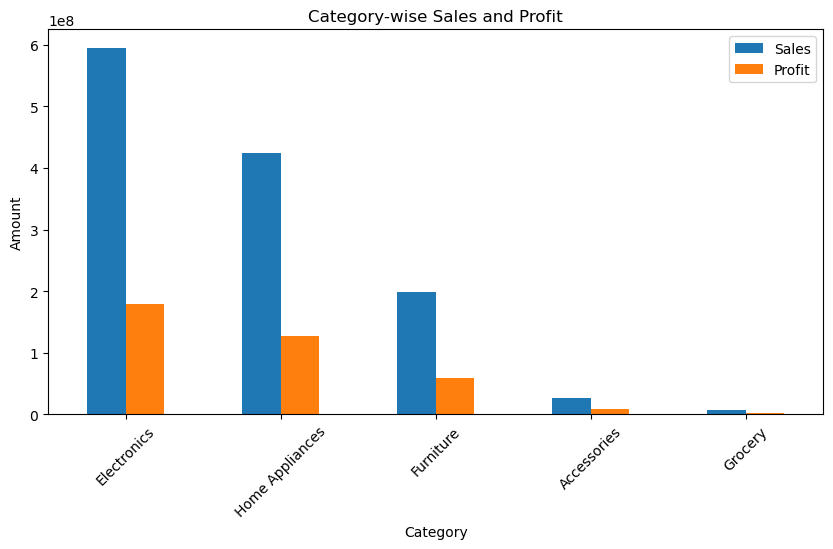

In [22]:
category_analysis.plot(kind="bar", figsize=(10,5))
plt.title("Category-wise Sales and Profit")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

In [23]:
top_products = (
    df.groupby("Product_Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

top_products

Product_Name
Laptop             2.718791e+08
Refrigerator       1.411351e+08
Smartphone         1.242788e+08
Air Conditioner    1.182990e+08
Washing Machine    1.053386e+08
Name: Sales, dtype: float64

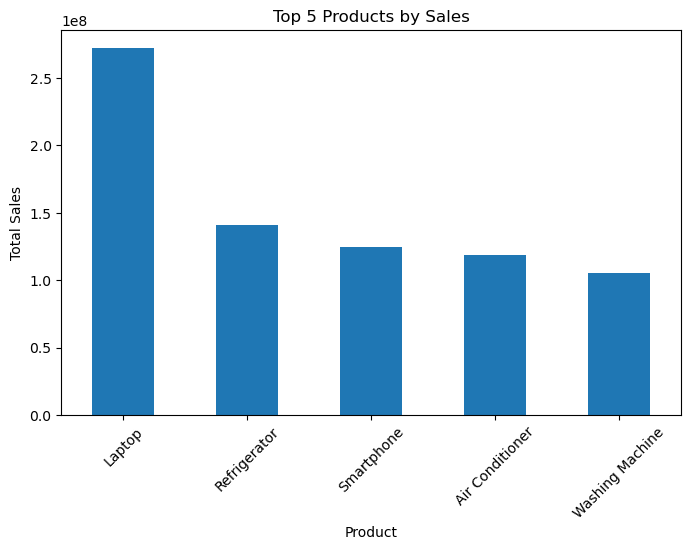

In [24]:
top_products.plot(kind="bar", figsize=(8,5))
plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [25]:
region_analysis = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

region_analysis

,Sales,Profit
Region,,
South,8.787091e+08,2.630818e+08
West,2.481419e+08,7.511185e+07
North,1.251372e+08,3.736499e+07


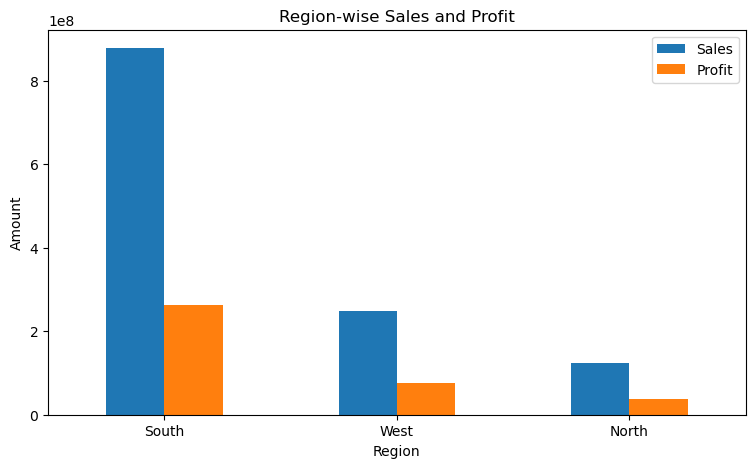

In [26]:
region_analysis.plot(kind="bar", figsize=(9,5))
plt.title("Region-wise Sales and Profit")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

In [27]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [28]:
monthly_sales = (
    df.set_index("Order_Date")
      .resample("ME")["Sales"]
      .sum()
)

monthly_sales

Order_Date
2024-01-31    45588038.34
2024-02-29    39400375.07
2024-03-31    40948565.20
2024-04-30    40154222.18
2024-05-31    36818869.18
2024-06-30    40282829.76
2024-07-31    41759506.80
2024-08-31    42296407.38
2024-09-30    40672815.97
2024-10-31    40156908.66
2024-11-30    38080697.45
2024-12-31    36745652.21
2025-01-31    46291885.64
2025-02-28    36941374.59
2025-03-31    43337871.95
2025-04-30    42153818.89
2025-05-31    40429731.58
2025-06-30    43952352.51
2025-07-31    43624496.31
2025-08-31    47364208.83
2025-09-30    40030477.50
2025-10-31    47946897.95
2025-11-30    45085308.34
2025-12-31    41350628.42
2026-01-31    44322114.09
2026-02-28    36184009.96
2026-03-31    44469203.77
2026-04-30    43282487.90
2026-05-31    42595337.38
2026-06-30    39721100.81
Freq: ME, Name: Sales, dtype: float64

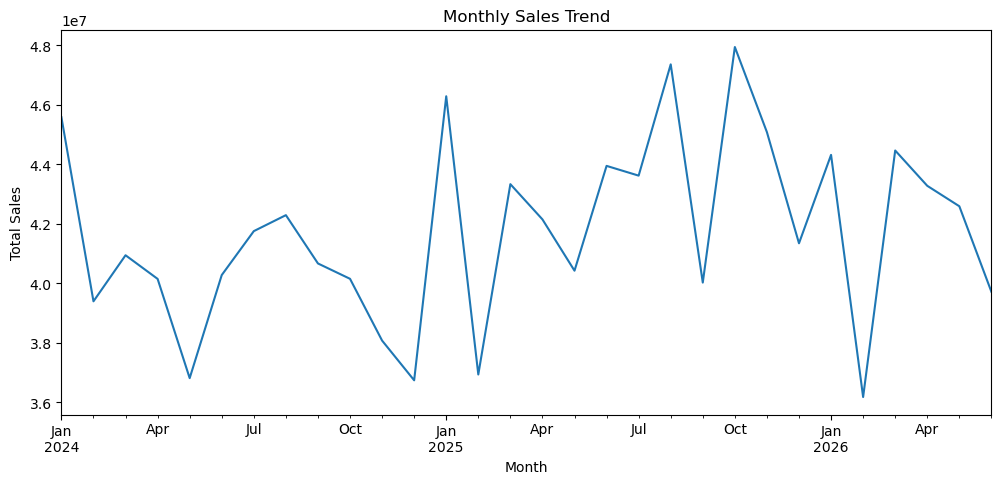

In [29]:
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [30]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", highest_sales)

print("Lowest Sales Month:", lowest_month)
print("Lowest Sales:", lowest_sales)

Highest Sales Month: 2025-10-31 00:00:00
Highest Sales: 47946897.95
Lowest Sales Month: 2026-02-28 00:00:00
Lowest Sales: 36184009.96


In [31]:
segment_analysis = (
    df.groupby("Customer_Segment")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

segment_analysis

,Sales,Profit
Customer_Segment,,
Consumer,7.281116e+08,2.187031e+08
Corporate,3.370810e+08,1.011074e+08
Home Office,1.867955e+08,5.574808e+07


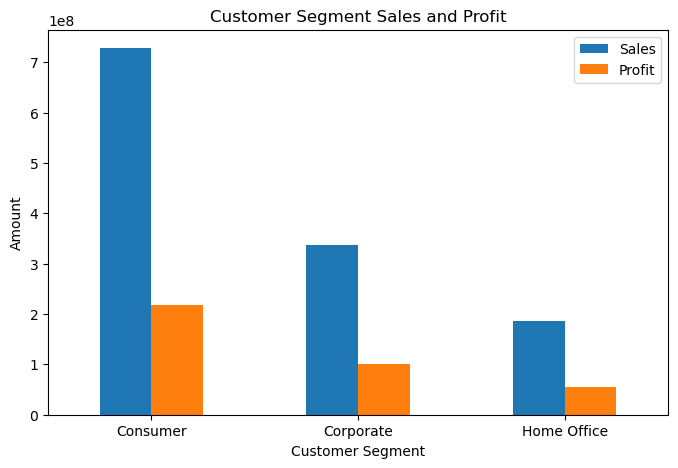

In [32]:
segment_analysis.plot(kind="bar", figsize=(8,5))
plt.title("Customer Segment Sales and Profit")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

In [33]:
payment_analysis = (
    df.groupby("Payment_Mode")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

payment_analysis

,Sales,Profit
Payment_Mode,,
UPI,4.062949e+08,1.218597e+08
Credit Card,3.157456e+08,9.374092e+07
Debit Card,2.467840e+08,7.447163e+07
Net Banking,1.848725e+08,5.551910e+07
Cash,9.829118e+07,2.996720e+07


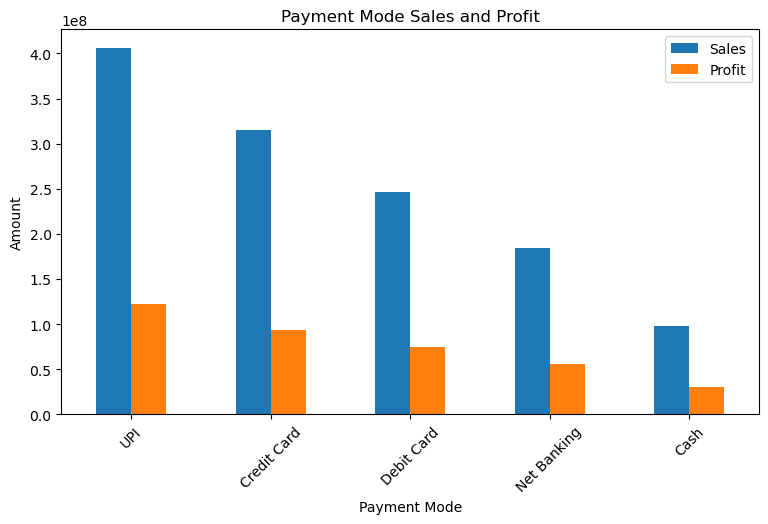

In [34]:
payment_analysis.plot(kind="bar", figsize=(9,5))
plt.title("Payment Mode Sales and Profit")
plt.xlabel("Payment Mode")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

In [35]:
inventory_analysis = (
    df.groupby("Product_Name")["Inventory_Level"]
      .mean()
      .sort_values()
)

inventory_analysis

Product_Name
Monitor            75.237954
Rice               75.244048
Office Chair       75.648520
Washing Machine    75.984587
Keyboard           76.070840
Tea                76.135932
Cooking Oil        76.395712
Coffee             76.618217
Mouse              76.768911
Webcam             76.783091
Headphones         76.813117
Microwave          76.861137
Snacks             77.028741
Smartphone         77.101907
Tablet             77.364346
Air Conditioner    77.455231
USB Cable          77.478372
Power Bank         77.494821
Desk               77.590050
Bookshelf          77.801611
Dining Table       78.183756
Laptop             78.390826
Sofa               78.926070
Vacuum Cleaner     79.631086
Refrigerator       79.807240
Name: Inventory_Level, dtype: float64

In [36]:
low_inventory = inventory_analysis[inventory_analysis < 50]

low_inventory

Series([], Name: Inventory_Level, dtype: float64)

In [38]:
low_inventory = (
    df.groupby("Product_Name")["Inventory_Level"]
      .mean()
      .sort_values()
      .head(5)
)

print(low_inventory)

Product_Name
Monitor            75.237954
Rice               75.244048
Office Chair       75.648520
Washing Machine    75.984587
Keyboard           76.070840
Name: Inventory_Level, dtype: float64


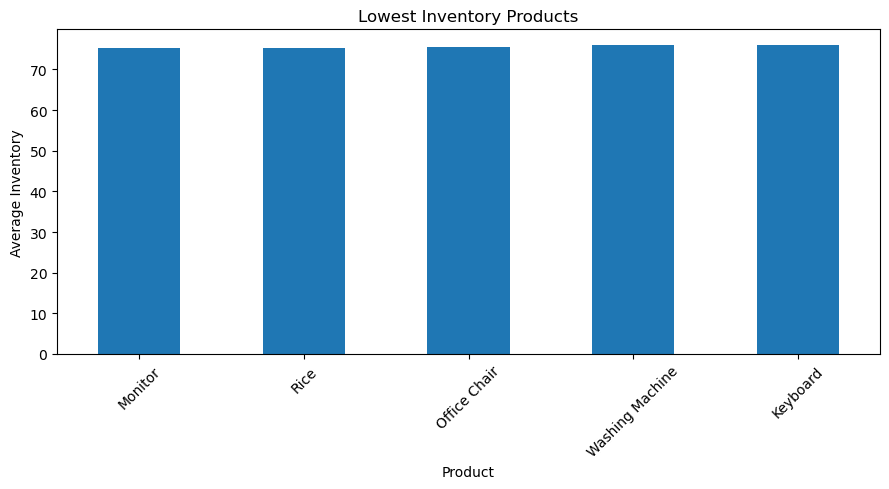

In [39]:
low_inventory.plot(kind="bar", figsize=(9,5))
plt.title("Lowest Inventory Products")
plt.xlabel("Product")
plt.ylabel("Average Inventory")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
profit_margin = (
    df.groupby("Product_Name")[["Sales", "Profit"]]
      .sum()
)

profit_margin["Profit_Margin_%"] = (
    profit_margin["Profit"] / profit_margin["Sales"] * 100
)

profit_margin = profit_margin.sort_values(
    "Profit_Margin_%", ascending=False
)

profit_margin

,Sales,Profit,Profit_Margin_%
Product_Name,,,
Bookshelf,1.819278e+07,5522261.32,30.354140
Desk,3.040451e+07,9211971.36,30.298040
Coffee,1.248102e+06,377659.25,30.258696
Webcam,1.075686e+07,3252165.89,30.233409
Power Bank,5.858236e+06,1768077.22,30.181051
Air Conditioner,1.182990e+08,35604508.13,30.097053
Refrigerator,1.411351e+08,42471277.13,30.092637
Headphones,2.239616e+07,6732798.42,30.062285
Snacks,6.742968e+05,202631.13,30.050735


In [41]:
profit_margin.head(5)

,Sales,Profit,Profit_Margin_%
Product_Name,,,
Bookshelf,18192777.85,5522261.32,30.354140
Desk,30404512.48,9211971.36,30.298040
Coffee,1248101.52,377659.25,30.258696
Webcam,10756861.33,3252165.89,30.233409
Power Bank,5858236.00,1768077.22,30.181051


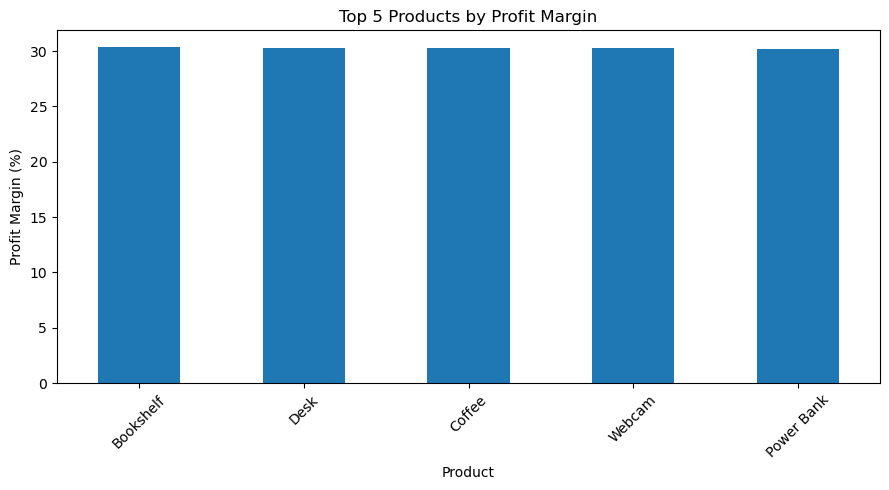

In [42]:
profit_margin["Profit_Margin_%"].head(5).plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Top 5 Products by Profit Margin")
plt.xlabel("Product")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Day"] = df["Order_Date"].dt.day
df["DayOfWeek"] = df["Order_Date"].dt.dayofweek
df["WeekOfYear"] = df["Order_Date"].dt.isocalendar().week.astype(int)

In [44]:
df[["Order_Date", "Year", "Month", "Day", "DayOfWeek", "WeekOfYear"]].head()

,Order_Date,Year,Month,Day,DayOfWeek,WeekOfYear
0,2024-01-01,2024,1,1,0,1
1,2024-01-01,2024,1,1,0,1
2,2024-01-01,2024,1,1,0,1
3,2024-01-01,2024,1,1,0,1
4,2024-01-01,2024,1,1,0,1


In [45]:
daily_sales = (
    df.groupby("Order_Date")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .reset_index()
)

daily_sales.head()

,Order_Date,Total_Sales,Total_Quantity
0,2024-01-01,2851192.83,141
1,2024-01-02,848361.51,79
2,2024-01-03,1586374.24,88
3,2024-01-04,486513.92,42
4,2024-01-05,960155.28,70


In [46]:
daily_sales.shape

(912, 3)

In [47]:
daily_sales = daily_sales.sort_values("Order_Date")

daily_sales["Lag_1"] = daily_sales["Total_Quantity"].shift(1)

daily_sales["Lag_7"] = daily_sales["Total_Quantity"].shift(7)

daily_sales["Rolling_7"] = (
    daily_sales["Total_Quantity"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily_sales.head(15)

,Order_Date,Total_Sales,Total_Quantity,Lag_1,Lag_7,Rolling_7
0,2024-01-01,2851192.83,141,NaN,NaN,NaN
1,2024-01-02,848361.51,79,141.0,NaN,NaN
2,2024-01-03,1586374.24,88,79.0,NaN,NaN
3,2024-01-04,486513.92,42,88.0,NaN,NaN
4,2024-01-05,960155.28,70,42.0,NaN,NaN
5,2024-01-06,1053481.76,76,70.0,NaN,NaN
6,2024-01-07,1019431.35,74,76.0,NaN,NaN
7,2024-01-08,1530638.54,118,74.0,141.0,81.428571
8,2024-01-09,1138184.32,99,118.0,79.0,78.142857
9,2024-01-10,2126278.49,118,99.0,88.0,81.000000


In [48]:
daily_sales.isnull().sum()

Order_Date        0
Total_Sales       0
Total_Quantity    0
Lag_1             1
Lag_7             7
Rolling_7         7
dtype: int64

In [49]:
ml_data = daily_sales.dropna().copy()

ml_data.shape

(905, 6)

In [51]:
daily_sales["Order_Date"] = pd.to_datetime(daily_sales["Order_Date"])

daily_sales["Year"] = daily_sales["Order_Date"].dt.year
daily_sales["Month"] = daily_sales["Order_Date"].dt.month
daily_sales["Day"] = daily_sales["Order_Date"].dt.day
daily_sales["DayOfWeek"] = daily_sales["Order_Date"].dt.dayofweek
daily_sales["WeekOfYear"] = daily_sales["Order_Date"].dt.isocalendar().week.astype(int)

In [52]:
ml_data = daily_sales.dropna().copy()

features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Lag_1",
    "Lag_7",
    "Rolling_7"
]

X = ml_data[features]
y = ml_data["Total_Quantity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (905, 8)
y shape: (905,)


In [53]:
split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (724, 8)
X_test : (181, 8)
y_train: (724,)
y_test : (181,)


In [1]:
from sklearn.ensemble import RandomForestRegressor

In [2]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [3]:
model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [8]:
import pandas as pd

df = pd.read_csv("Retail_Sales_Demand_Forecasting_30000.csv")

print(df.shape)

(30000, 20)


In [9]:
daily_sales = (
    df.groupby("Order_Date")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .reset_index()
)

print(daily_sales.shape)

(912, 3)


In [10]:
daily_sales["Order_Date"] = pd.to_datetime(daily_sales["Order_Date"])

daily_sales["Year"] = daily_sales["Order_Date"].dt.year
daily_sales["Month"] = daily_sales["Order_Date"].dt.month
daily_sales["DayOfWeek"] = daily_sales["Order_Date"].dt.dayofweek

print(daily_sales.head())

  Order_Date  Total_Sales  Total_Quantity  Year  Month  DayOfWeek
0 2024-01-01   2851192.83             141  2024      1          0
1 2024-01-02    848361.51              79  2024      1          1
2 2024-01-03   1586374.24              88  2024      1          2
3 2024-01-04    486513.92              42  2024      1          3
4 2024-01-05    960155.28              70  2024      1          4


In [11]:
daily_sales = daily_sales.sort_values("Order_Date")

daily_sales["Lag_1"] = daily_sales["Total_Quantity"].shift(1)
daily_sales["Lag_7"] = daily_sales["Total_Quantity"].shift(7)

daily_sales["Rolling_7"] = (
    daily_sales["Total_Quantity"]
    .shift(1)
    .rolling(7)
    .mean()
)

print(daily_sales.head(10))

  Order_Date  Total_Sales  Total_Quantity  Year  Month  DayOfWeek  Lag_1  \
0 2024-01-01   2851192.83             141  2024      1          0    NaN   
1 2024-01-02    848361.51              79  2024      1          1  141.0   
2 2024-01-03   1586374.24              88  2024      1          2   79.0   
3 2024-01-04    486513.92              42  2024      1          3   88.0   
4 2024-01-05    960155.28              70  2024      1          4   42.0   
5 2024-01-06   1053481.76              76  2024      1          5   70.0   
6 2024-01-07   1019431.35              74  2024      1          6   76.0   
7 2024-01-08   1530638.54             118  2024      1          0   74.0   
8 2024-01-09   1138184.32              99  2024      1          1  118.0   
9 2024-01-10   2126278.49             118  2024      1          2   99.0   

   Lag_7  Rolling_7  
0    NaN        NaN  
1    NaN        NaN  
2    NaN        NaN  
3    NaN        NaN  
4    NaN        NaN  
5    NaN        NaN  
6    NaN 

In [12]:
ml_data = daily_sales.dropna().copy()

features = [
    "Year",
    "Month",
    "DayOfWeek",
    "Lag_1",
    "Lag_7",
    "Rolling_7"
]

X = ml_data[features]
y = ml_data["Total_Quantity"]

print("X:", X.shape)
print("y:", y.shape)

X: (905, 6)
y: (905,)


In [13]:
ml_data = daily_sales.dropna().copy()

features = [
    "Year",
    "Month",
    "DayOfWeek",
    "Lag_1",
    "Lag_7",
    "Rolling_7"
]

X = ml_data[features]
y = ml_data["Total_Quantity"]

print("X:", X.shape)
print("y:", y.shape)

X: (905, 6)
y: (905,)


In [14]:
split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (724, 6)
X_test : (181, 6)


In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [16]:
y_pred = model.predict(X_test)

print(y_pred[:10])


[ 99.6    88.08   98.95  104.395  98.615  91.105  95.34   95.935  86.485
 101.525]


In [17]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 99.6    88.08   98.95  104.395  98.615  91.105  95.34   95.935  86.485
 101.525]


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

MAE : 14.9
RMSE: 19.17
R²  : -0.09


In [19]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
5,Rolling_7,0.259362
4,Lag_7,0.240143
3,Lag_1,0.223812
1,Month,0.134755
2,DayOfWeek,0.111883
0,Year,0.030045


NameError: name 'plt' is not defined

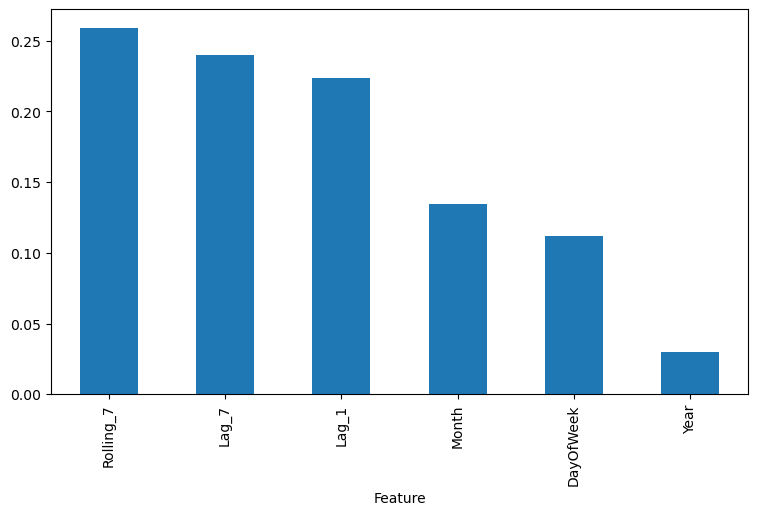

In [20]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(9,5),
    legend=False
)

plt.title("Feature Importance - Demand Forecasting")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
forecast_results = ml_data.iloc[split_index:][["Order_Date", "Total_Quantity"]].copy()

forecast_results["Predicted_Demand"] = y_pred

forecast_results.to_csv(
    "Demand_Forecast_Results.csv",
    index=False
)

print(forecast_results.head())

    Order_Date  Total_Quantity  Predicted_Demand
731 2026-01-01             125            99.600
732 2026-01-02             101            88.080
733 2026-01-03              86            98.950
734 2026-01-04              88           104.395
735 2026-01-05             107            98.615


In [22]:
forecast_results.to_csv("Demand_Forecast_Results.csv", index=False)

In [23]:
print(forecast_results.columns.tolist())

['Order_Date', 'Total_Quantity', 'Predicted_Demand']


In [24]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["R2 Score"],
    "Value": [r2]
})

metrics.to_csv("Model_Metrics.csv", index=False)

print("R² Score:", round(r2, 3))

R² Score: -0.09


In [25]:
daily_sales = daily_sales.sort_values("Order_Date").copy()

daily_sales["Lag_14"] = daily_sales["Total_Quantity"].shift(14)

daily_sales["Rolling_14"] = (
    daily_sales["Total_Quantity"]
    .shift(1)
    .rolling(14)
    .mean()
)

daily_sales["Rolling_30"] = (
    daily_sales["Total_Quantity"]
    .shift(1)
    .rolling(30)
    .mean()
)

print(daily_sales[[
    "Order_Date",
    "Total_Quantity",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_7",
    "Rolling_14",
    "Rolling_30"
]].tail())

    Order_Date  Total_Quantity  Lag_1  Lag_7  Lag_14  Rolling_7  Rolling_14  \
907 2026-06-26              64   72.0   78.0    66.0  87.857143   92.714286   
908 2026-06-27             103   64.0  100.0    88.0  85.857143   92.571429   
909 2026-06-28             103  103.0   86.0    82.0  86.285714   93.642857   
910 2026-06-29              95  103.0   81.0   112.0  88.714286   95.142857   
911 2026-06-30              85   95.0  105.0   104.0  90.714286   93.928571   

     Rolling_30  
907   94.533333  
908   93.100000  
909   93.833333  
910   94.266667  
911   93.933333  


In [26]:
ml_data = daily_sales.dropna().copy()

features = [
    "Year",
    "Month",
    "DayOfWeek",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_7",
    "Rolling_14",
    "Rolling_30"
]

X = ml_data[features]
y = ml_data["Total_Quantity"]

print("X:", X.shape)
print("y:", y.shape)

X: (882, 9)
y: (882,)


In [27]:
split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (705, 9)
X_test : (177, 9)


In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Improved model training completed!")

Improved model training completed!


In [29]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[91.38641551 91.53139493 88.93994418 90.74212841 83.93004168 88.32170586
 93.20803481 96.37024511 89.64841067 89.13765948]


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Improved Model Results")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

Improved Model Results
MAE : 15.2
RMSE: 19.24
R²  : -0.092


In [31]:
improved_metrics = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

improved_metrics.to_csv(
    "Improved_Model_Metrics.csv",
    index=False
)

print(improved_metrics)

     Metric      Value
0  R2 Score  -0.092265
1       MAE  15.196512
2      RMSE  19.236840


In [32]:
improved_forecast = ml_data.iloc[split_index:][
    ["Order_Date", "Total_Quantity"]
].copy()

improved_forecast["Predicted_Demand"] = y_pred

improved_forecast.to_csv(
    "Improved_Demand_Forecast.csv",
    index=False
)

print(improved_forecast.head())

    Order_Date  Total_Quantity  Predicted_Demand
735 2026-01-05             107         91.386416
736 2026-01-06              88         91.531395
737 2026-01-07             113         88.939944
738 2026-01-08              99         90.742128
739 2026-01-09             102         83.930042


In [33]:
print("===== FINAL MODEL RESULTS =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

===== FINAL MODEL RESULTS =====
MAE : 15.2
RMSE: 19.24
R²  : -0.092


In [34]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Extra Trees Results")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

Extra Trees Results
MAE : 14.91
RMSE: 18.76
R²  : -0.039


In [36]:
print("Demand mean:", round(y_test.mean(), 2))
print("Baseline MAE:", round(np.mean(np.abs(y_test - y_train.mean())), 2))

Demand mean: 94.75
Baseline MAE: 14.65


In [37]:
mae_result = pd.DataFrame({
    "Metric": ["MAE"],
    "Value": [mae]
})

mae_result.to_csv("Final_Model_MAE.csv", index=False)

print(mae_result)

  Metric      Value
0    MAE  14.914998
